**Introduction to AI Project: Detecting Fake and Real News**


---


Part 1: Data Preparation

In [ ]:
#Import necessary libraries
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
#read datasets, ensure datasets available
fake_df = pd.read_csv("Fake.csv", nrows=200, quotechar='"', doublequote=True, engine='c')
true_df = pd.read_csv("True.csv", nrows=200, quotechar='"', doublequote=True, engine='c')

# Create labels for each news: 0 = Fake, 1 = Real
fake_df['label'] = 0
true_df['label'] = 1

# Combine both files
df = pd.concat([fake_df, true_df], axis=0).reset_index(drop=True)
df = df[['title', 'text', 'label']] #give columns names
df.head() #display first 5 rows

,title,text,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,0


In [ ]:
import re #support for regular expressions

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation, numbers, and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = nltk.word_tokenize(text)
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    # Lemmatization
    tokens_lemmatized = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens_lemmatized)

# Apply preprocessing to the news text
df['clean_text'] = df['text'].apply(preprocess_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,Donald Trump just couldn t wish all Americans ...,donald trump wish american happy new year leav...
1,House Intelligence Committee Chairman Devin Nu...,house intelligence committee chairman devin nu...
2,"On Friday, it was revealed that former Milwauk...",friday revealed former milwaukee sheriff david...
3,"On Christmas day, Donald Trump announced that ...",christmas day donald trump announced would bac...
4,Pope Francis used his annual Christmas Day mes...,pope francis used annual christmas day message...


In [ ]:
bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(df['clean_text'])

print("BoW shape:", X_bow.shape)

BoW shape: (400, 5000)


In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (400, 5000)


In [ ]:
#create separate training and testing datasets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, df['label'], test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Test samples:", X_test.shape)

Training samples: (320, 5000)
Test samples: (80, 5000)


In [ ]:
print("Shape of X_train:", X_train.shape)
print("Type of X_train:", type(X_train))

Shape of X_train: (320, 5000)
Type of X_train: <class 'scipy.sparse._csr.csr_matrix'>


Part 2: ML model 1 - Naive Bayes model

Accuracy: 0.95

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      0.91      0.95        44
        Real       0.90      1.00      0.95        36

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.96      0.95      0.95        80



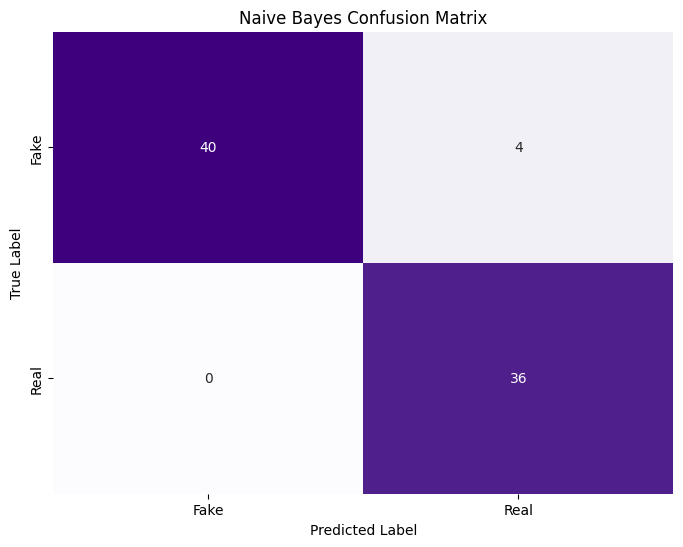

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train the model
nb = MultinomialNB()
nb.fit(X_train, y_train)

# Test the model
y_pred = nb.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Naive Bayes Confusion Matrix')
plt.show()


Part 3: ML model 2 - Random Forests model

Accuracy: 0.9888888888888889

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       181
           1       0.98      1.00      0.99       179

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



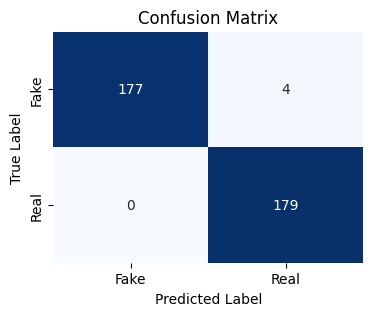

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Try changing test size and random state
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_tfidf, df['label'], test_size=0.9, random_state= 25)

#train model
model = RandomForestClassifier(n_estimators=500, random_state=50)
model.fit(X_train1, y_train1)

#test model
y_pred = model.predict(X_test1)

#evaluate model
accuracy = accuracy_score(y_test1, y_pred)
print("Accuracy:", accuracy)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test1, y_pred))

# Generate Confusion Matrix
cm = confusion_matrix(y_test1, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Part 4: DL model: CNN

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training CNN model...

Evaluating CNN model...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
CNN Accuracy: 0.9875

Classification Report (CNN):
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        39
           1       0.98      1.00      0.99        41

    accuracy                           0.99        80
   macro avg       0.99      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



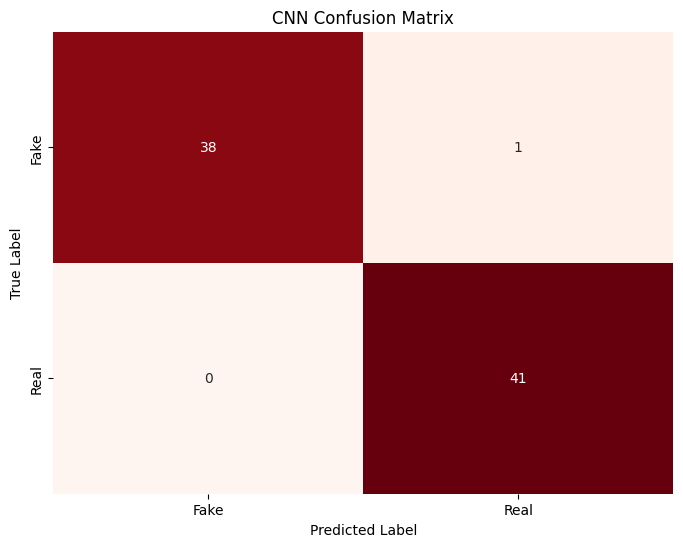

In [ ]:
#import necessary libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import matplotlib.pyplot as plt

#Try changing test size and random state
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_tfidf, df['label'], test_size=0.2, random_state= 100)

# Convert sparse matrices to dense arrays for Keras
cv_train = X_train1.toarray()
cv_test = X_test1.toarray()

#Define model
model = Sequential()
model.add(Dense(units = 100 , activation = 'relu' , input_dim = cv_train.shape[1]))
model.add(Dense(units = 50 , activation = 'relu'))
model.add(Dense(units = 25 , activation = 'relu'))
model.add(Dense(units = 10 , activation = 'relu'))
model.add(Dense(units = 1 , activation = 'sigmoid'))

#compile model
model.compile(optimizer = 'adam' , loss = 'binary_crossentropy' , metrics = ['accuracy'])

#fit model
print("\nTraining CNN model...")
history = model.fit(cv_train, y_train1, epochs = 6, verbose=0) # Set verbose to 0 to suppress output per epoch

#Evaluation
print("\nEvaluating CNN model...")

pred_prob = model.predict(cv_test)
pred = (pred_prob > 0.5).astype(int)

cnn_accuracy = accuracy_score(y_test1, pred)
print(f"CNN Accuracy: {cnn_accuracy:.4f}")

print("\nClassification Report (CNN):")
print(classification_report(y_test1, pred))

# Confusion Matrix
cm_cv = confusion_matrix(y_test1, pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cv, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CNN Confusion Matrix')
plt.show()

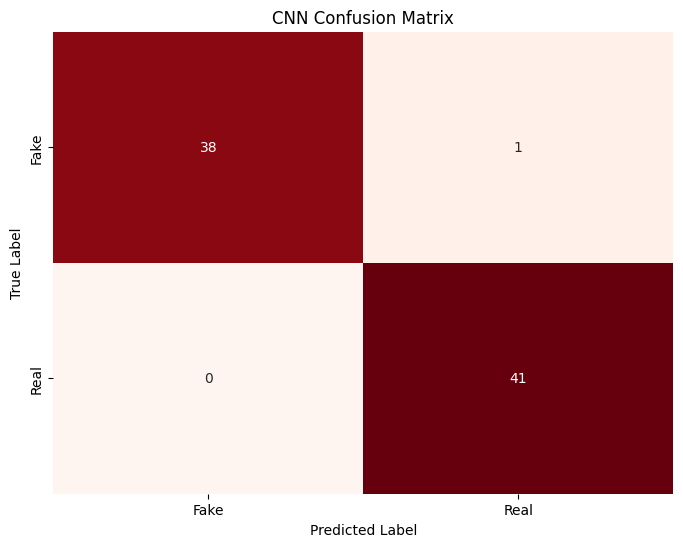

In [ ]:
# Confusion Matrix
cm_cv = confusion_matrix(y_test1, pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cv, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CNN Confusion Matrix')
plt.show()